# Unstructured Data Lab: QuickKart Customer Reviews (Free Text)

**Course:** Big Data Analytics — MBA BA, Trim IV
**Business Case:** QuickKart's customer support team is drowning in text — can we find the real problem at scale?

---

### Why unstructured data is the hardest of the three

- **Structured** (Notebook 1): every order is a row with fixed columns.
- **Semi-structured** (Notebook 2): every order is a JSON document — fields can vary, but there's still a recognizable key-value shape.
- **Unstructured** (this notebook): customer reviews are just... sentences. No columns, no keys, no guaranteed structure at all. A computer has *zero* built-in understanding of what's inside a block of text until we impose some structure on it ourselves.

Roughly 80–90% of the data most companies generate — reviews, support tickets, chat logs, call transcripts, images — is unstructured. QuickKart's customer support inbox is exactly this kind of data.

### The business question

> **"Customer complaints are up. Support agents are manually reading hundreds of reviews a day. Can we automatically surface what customers are actually complaining about, at scale, without reading every single review by hand?"**

This is a real, common first step into text analytics: before any fancy NLP or sentiment models, most companies start with **word frequency counting** — literally the same MapReduce word-count pattern used to teach distributed computing in every Hadoop course ever written. It turns out the "hello world" of MapReduce is also a legitimate first pass at a real business problem.


In [ ]:
import random, os, shutil
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

random.seed(3)

# Building blocks for synthetic reviews: mix of praise, complaints, and neutral filler
positive_snippets = [
    "delivery was super fast", "great quality produce", "app is really easy to use",
    "loved the packaging", "customer service was helpful", "fresh vegetables every time",
    "amazing discounts this week", "quick and reliable service",
]
negative_snippets = [
    "delivery was very late", "items arrived damaged", "app kept crashing at checkout",
    "wrong items delivered", "customer service did not respond", "produce was rotten",
    "delivery driver was rude", "order got cancelled without warning", "payment failed twice",
    "delivery was late again", "missing items in my order",
]
neutral_snippets = [
    "ordered groceries for the week", "used the app on my phone", "paid using UPI",
    "placed the order in the evening", "used a promo code at checkout",
]

categories = ["Fruits & Vegetables", "Dairy", "Snacks", "Beverages", "Household"]

def generate_review():
    n_snippets = random.randint(1, 3)
    pool = positive_snippets + negative_snippets + neutral_snippets
    # Weight complaints slightly higher, matching the "complaints are up" business scenario
    weights = ([1] * len(positive_snippets)) + ([2] * len(negative_snippets)) + ([1] * len(neutral_snippets))
    chosen = random.choices(pool, weights=weights, k=n_snippets)
    category = random.choice(categories)
    return f"Order category: {category}. " + ". ".join(chosen) + "."

N_REVIEWS = 900
reviews = [generate_review() for _ in range(N_REVIEWS)]

print(f"Generated {N_REVIEWS} customer reviews. Example:\n")
for r in reviews[:3]:
    print("-", r)

This is what unstructured data looks like: free-form sentences with no guaranteed vocabulary, no fixed length, and business-relevant signal (which category, whether it's a complaint) buried inside plain English rather than sitting in a clean column.


In [2]:
# Store reviews as raw .txt files split across 3 "node" folders — same storage
# concept as the HDFS notebook, just applied to text instead of CSV rows.
if os.path.exists("text_cluster"):
    shutil.rmtree("text_cluster")

for node in ["node1", "node2", "node3"]:
    os.makedirs(f"text_cluster/{node}", exist_ok=True)

chunk_size = len(reviews) // 3
chunks = [reviews[0:chunk_size], reviews[chunk_size:2*chunk_size], reviews[2*chunk_size:]]

for i, (node, chunk) in enumerate(zip(["node1", "node2", "node3"], chunks), start=1):
    path = f"text_cluster/{node}/reviews_block{i}.txt"
    with open(path, "w") as f:
        f.write("\n".join(chunk))
    print(f"{path}: {len(chunk)} reviews")


text_cluster/node1/reviews_block1.txt: 300 reviews
text_cluster/node2/reviews_block2.txt: 300 reviews
text_cluster/node3/reviews_block3.txt: 300 reviews


## MapReduce Word Count — the classic starting point for text at scale

### Map phase
Each node reads its own block of reviews and counts word frequency *independently* — no coordination with other nodes needed yet.

### Shuffle + Reduce phase
Word counts from all 3 nodes get combined into one global frequency table.


In [ ]:
from collections import Counter

STOPWORDS = {
    "the", "a", "an", "was", "is", "at", "in", "for", "my", "this", "and", "to",
    "of", "on", "with", "again", "order", "category", "used", "ordered",
}

def clean_and_tokenize(text):
    text = text.lower().replace(".", " ").replace(",", " ")
    words = text.split()
    return [w for w in words if w not in STOPWORDS and len(w) > 2]

def map_word_count(filepath):
    """MAP: tokenize this node's block and count word frequency, independently."""
    with open(filepath) as f:
        text = f.read()
    words = clean_and_tokenize(text)
    return Counter(words)

block_paths = [
    "text_cluster/node1/reviews_block1.txt",
    "text_cluster/node2/reviews_block2.txt",
    "text_cluster/node3/reviews_block3.txt",
]

# Use ThreadPoolExecutor for Windows compatibility (no multiprocessing issues)
with ThreadPoolExecutor(max_workers=3) as executor:
    partial_counts = list(executor.map(map_word_count, block_paths))

for i, counter in enumerate(partial_counts, start=1):
    print(f"Top 5 words from node{i} (independent, before combining):")
    print(counter.most_common(5))
    print()

In [4]:
# SHUFFLE + REDUCE: merge all 3 nodes' partial word counts into one global count
global_counts = Counter()
for partial in partial_counts:
    global_counts.update(partial)

top_words = pd.DataFrame(global_counts.most_common(15), columns=["word", "count"])
top_words


,word,count
0,category:,900
1,delivery,341
2,items,337
3,vegetables,223
4,service,208
5,late,202
6,snacks,198
7,app,194
8,fruits,184
9,beverages,181


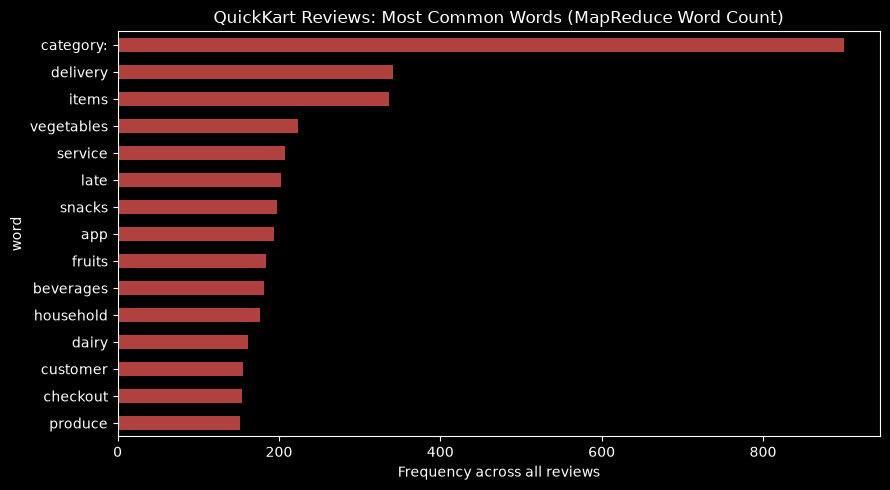

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
top_words.set_index("word")["count"].sort_values().plot(kind="barh", ax=ax, color="#B0413E")
ax.set_xlabel("Frequency across all reviews")
ax.set_title("QuickKart Reviews: Most Common Words (MapReduce Word Count)")
plt.tight_layout()
plt.show()


Notice words like *"delivery"*, *"late"*, *"damaged"*, and *"crashing"* should be surfacing near the top — the word-count alone, with zero fancy NLP, is already pointing straight at where the operational problems are.


## Turning Word Counts into a Business Answer: Simple Complaint Detection

Raw word frequency is useful, but a business stakeholder wants a sharper answer: **what fraction of reviews are actual complaints, and about what?** We'll use a lightweight keyword-matching approach — the same "good enough to be useful" logic companies often reach for before investing in a full sentiment-analysis model.


In [6]:
complaint_keywords = {
    "late", "damaged", "wrong", "crashing", "rude", "cancelled",
    "rotten", "failed", "missing", "respond",
}

def classify_review(text):
    words = set(clean_and_tokenize(text))
    return "Complaint" if words & complaint_keywords else "Non-complaint"

review_df = pd.DataFrame({"review": reviews})
review_df["category"] = review_df["review"].str.extract(r"Order category: ([^.]+)\.")
review_df["classification"] = review_df["review"].apply(classify_review)

review_df.head(8)


,review,category,classification
0,Order category: Dairy. delivery driver was rude.,Dairy,Complaint
1,Order category: Household. paid using UPI. cus...,Household,Complaint
2,Order category: Beverages. delivery driver was...,Beverages,Complaint
3,Order category: Beverages. produce was rotten....,Beverages,Complaint
4,Order category: Dairy. missing items in my ord...,Dairy,Complaint
5,Order category: Household. order got cancelled...,Household,Complaint
6,Order category: Fruits & Vegetables. payment f...,Fruits & Vegetables,Complaint
7,Order category: Household. delivery was late a...,Household,Complaint


In [7]:
# Business-facing summary: complaint rate overall, and by category
overall_rate = (review_df["classification"] == "Complaint").mean() * 100
print(f"Overall complaint rate: {overall_rate:.1f}% of reviews\n")

by_category = (
    review_df.groupby("category")["classification"]
    .apply(lambda s: (s == "Complaint").mean() * 100)
    .sort_values(ascending=False)
    .round(1)
)
print("Complaint rate by category (%):")
by_category


Overall complaint rate: 82.3% of reviews

Complaint rate by category (%):


category
Fruits & Vegetables    87.0
Household              82.4
Snacks                 81.3
Beverages              80.7
Dairy                  80.1
Name: classification, dtype: float64

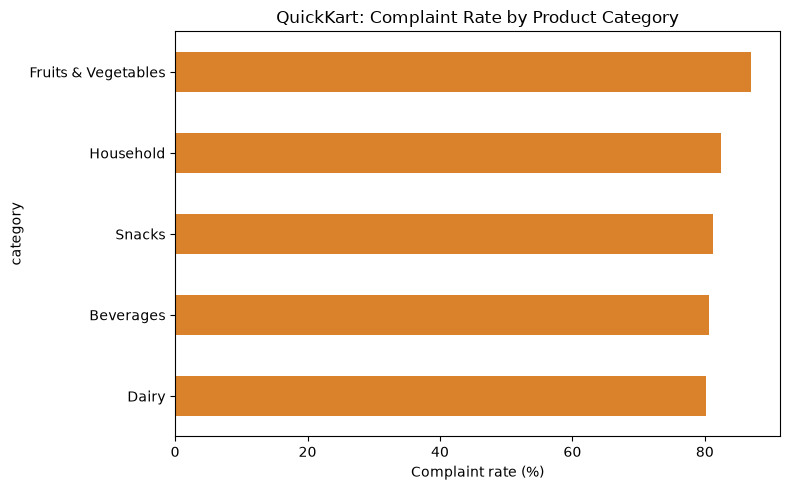

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
by_category.sort_values().plot(kind="barh", ax=ax, color="#D9822B")
ax.set_xlabel("Complaint rate (%)")
ax.set_title("QuickKart: Complaint Rate by Product Category")
plt.tight_layout()
plt.show()


### Business insight

Support leadership no longer has to read all 900 reviews to know where to focus. If, say, **Household** or **Dairy** categories show the highest complaint rate, that's an immediately actionable signal — pointing operations toward packaging, cold-chain logistics, or delivery-time issues for those specific product lines, without a single review being read manually.

## Recap: Structured vs. Semi-Structured vs. Unstructured

| | Structured (Notebook 1) | Semi-Structured (Notebook 2) | Unstructured (this notebook) |
|---|---|---|---|
| Example | Orders CSV | Nested JSON order documents | Free-text customer reviews |
| Schema | Fixed, known upfront | Flexible, key-value shaped | None — plain text |
| Effort before analysis | None — already tabular | Flatten nested structure | Tokenize, clean, classify |
| Typical first analytics step | groupby / aggregation | json_normalize + groupby | Word count → keyword rules → (eventually) NLP models |
| Real tools at scale | Hive, SQL-on-Hadoop | Spark JSON reader, MongoDB, Hive w/ SerDe | Spark NLP, Elasticsearch, LLM-based classification |

### Discussion questions for class

1. Our complaint classifier is just keyword matching — what kinds of complaints would it completely miss? (Sarcasm, polite-but-negative phrasing, complaints that don't use our exact keyword list.)
2. If QuickKart had 50 million reviews instead of 900, which part of this notebook would need real distributed infrastructure (a real Hadoop/Spark cluster) instead of a laptop's multiprocessing?
3. Compare the *effort required before you can ask a business question* across all three notebooks. What does that tell you about why unstructured data projects tend to take longer and cost more than structured-data projects?
4. Where might this simple keyword approach give a **false sense of confidence** to a business stakeholder who doesn't know its limitations?
